# Editing Fraser River Hydrograph

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
fraser['date'] = pd.to_datetime(fraser[['year','month','day']])
# fraser = fraser.drop(columns=['year','month','day'])
fraser

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_463471/164222624.py:1: SyntaxWarning: invalid escape sequence '\s'
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
/tmp/ipykernel_463471/164222624.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
/tmp/ipykernel_463471/164222624.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-

,year,month,day,flow,date
0,1912,3.0,1.0,538.000,1912-03-01
1,1912,3.0,2.0,538.000,1912-03-02
2,1912,3.0,3.0,538.000,1912-03-03
3,1912,3.0,4.0,538.000,1912-03-04
4,1912,3.0,5.0,538.000,1912-03-05
...,...,...,...,...,...
41712,2026,5.0,17.0,5815.868,2026-05-17
41713,2026,5.0,18.0,5748.229,2026-05-18
41714,2026,5.0,19.0,5462.604,2026-05-19
41715,2026,5.0,20.0,5120.035,2026-05-20


In [3]:
data = fraser[(fraser.year>=2018)&(fraser.year<=2022)]

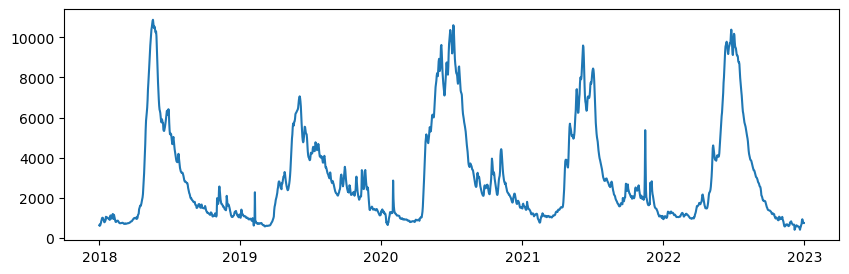

In [4]:
fig, ax = plt.subplots(1,1,figsize=[10,3])

ax.plot(data.date,data.flow)

## Morrison et al. 2002
using change to peak, min, and total estimates to squash the current hydrograph. Also need to shift by 10 days. 

In [5]:
Mpeakchange = 8443-7241 # want peak flow to be about 1000 less than before - Morrison2002 table 2
Mminchange = 974-768 # want minimum flow to be about 200 more than before
print(Mpeakchange)
print(Mminchange)

1202
206


In [6]:
np.min(data.flow) # note that this is much lower than the present day minimum flow in Morrison2002 (768, Table 2)

410.8264

In [7]:
np.max(data.flow) # note that this is much higher than the present day peak flow in Morrison2002 (Table 2)

10876.47

In [8]:
# since it seems that we were measuring at different points (peak and minimum very different than reported)
# take percentage change from Morrison 2002 (measured at hope) to get the changes to apply here
peakchange = (Mpeakchange/8443)*np.max(data.flow)
minchange = (Mminchange/768)*np.min(data.flow)

print(peakchange)
print(minchange)

1548.444503138695
110.19562291666666


In [13]:
runoff = data.flow

total = np.sum(runoff) # don't want annual total to significantly change
avg = np.mean(runoff)
print(total)
print(avg)

5421895.6945
2969.2747505476455


In [14]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.8475019812443411
new total = 4796284.55, or a -11.54% change


In [15]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 470
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
print(f"new mean = {np.round(np.mean(newrun),2)}, or a {np.round((np.mean(newrun)/avg*100)-100,2)}% change")

factor = 0.8042894315843871
new total = 5420210.61, or a -0.03% change
new mean = 2968.35, or a -0.03% change


In [22]:
# using the min change from the full timeseries analysis lets calculate what percentage of the present day min that value is
newminchange = minchange+increasemin
print(newminchange/np.min(runoff))

1.4122647008971836


algorhythm becomes flow*0.8+(minflow*1.4) 

In [30]:
data['Morrison2002'] = runoff*0.8 + (np.min(runoff)*1.4)

# and check
print(f"new total = {np.round(np.sum(data.Morrison2002),2)}, or a {np.round((np.sum(data.Morrison2002)/total*100)-100,2)}% change")
print(f"new mean = {np.round(np.mean(data.Morrison2002),2)}, or a {np.round((np.mean(data.Morrison2002)/avg*100)-100,2)}% change")

new total = 5387753.16, or a -0.63% change
new mean = 2950.58, or a -0.63% change


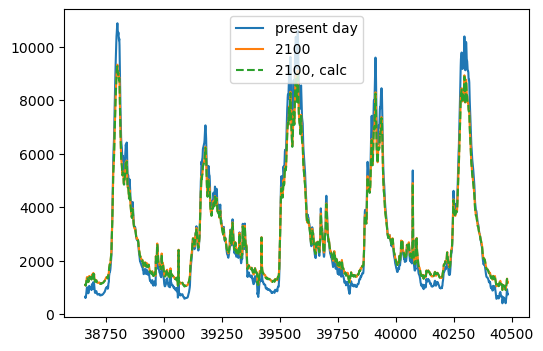

In [31]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.plot(data.Morrison2002, ls='--', label='2100, calc')
ax.legend()

## Ficklin et al. 2016
Using monthly factors of change from Columbia river watershed (also snowmelt dominated) to change the Fraser. 

In [34]:
# based on the difference between the CMIP5 enssemble mean and the historical columbia river hydrograph in Fickin2016 (figure 5) this is our monthly scaling of flow:
monthly_factor = np.array([
    2.5,  # Jan
    2.6,  # Feb
    2.3,  # Mar
    1.4,  # Apr
    0.8,  # May
    0.5,  # Jun
    0.5,  # Jul
    0.7,  # Aug
    0.8,  # Sep
    0.9,  # Oct
    1.2,  # Nov
    2.2   # Dec
])

In [51]:
data['ficklin2016'] = np.nan
for m in range(1, 13):
    mask = data["month"].astype(int) == m
    data.loc[mask, "ficklin2016"] = data.loc[mask, "flow"] * monthly_factor[m - 1]

data

,year,month,day,flow,date,Morrison2002,ficklin2016
38659,2018,1.0,1.0,631.6214,2018-01-01,1080.45408,1579.05350
38660,2018,1.0,2.0,676.3056,2018-01-02,1116.20144,1690.76400
38661,2018,1.0,3.0,620.9424,2018-01-03,1071.91088,1552.35600
38662,2018,1.0,4.0,675.9213,2018-01-04,1115.89400,1689.80325
38663,2018,1.0,5.0,738.8530,2018-01-05,1166.23936,1847.13250
...,...,...,...,...,...,...,...
40480,2022,12.0,27.0,934.9549,2022-12-27,1323.12088,2056.90078
40481,2022,12.0,28.0,872.9653,2022-12-28,1273.52920,1920.52366
40482,2022,12.0,29.0,787.6319,2022-12-29,1205.26248,1732.79018
40483,2022,12.0,30.0,746.9826,2022-12-30,1172.74304,1643.36172


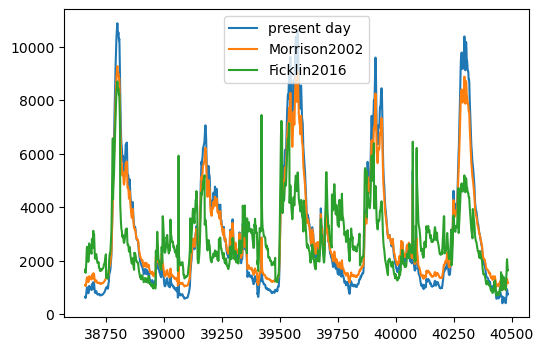

In [53]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(data.Morrison2002, label='Morrison2002')
ax.plot(data.ficklin2016, label='Ficklin2016')
ax.legend()

## Elsner2010

In [97]:
# based on the difference between the CMIP4 A1B enssemble mean and the historical columbia river hydrograph in Elsner2010 (figure 8) this is our monthly scaling of flow:
monthly_factor = np.array([
    1.7,  # Jan
    1.8,  # Feb
    1.5,  # Mar
    1.3,  # Apr
    1.1,  # May
    0.9,  # Jun
    0.6,  # Jul
    0.7,  # Aug
    0.8,  # Sep
    1.0,  # Oct
    1.3,  # Nov
    1.5   # Dec
])
# similar to Ficklin2016 but less extreme

In [98]:
data['elsner2010'] = np.nan
for m in range(1, 13):
    mask = data["month"].astype(int) == m
    data.loc[mask, "elsner2010"] = data.loc[mask, "flow"] * monthly_factor[m - 1]

data

,year,month,day,flow,date,Morrison2002,ficklin2016,elsner2010
38659,2018,1.0,1.0,631.6214,2018-01-01,1080.45408,1579.05350,1073.75638
38660,2018,1.0,2.0,676.3056,2018-01-02,1116.20144,1690.76400,1149.71952
38661,2018,1.0,3.0,620.9424,2018-01-03,1071.91088,1552.35600,1055.60208
38662,2018,1.0,4.0,675.9213,2018-01-04,1115.89400,1689.80325,1149.06621
38663,2018,1.0,5.0,738.8530,2018-01-05,1166.23936,1847.13250,1256.05010
...,...,...,...,...,...,...,...,...
40480,2022,12.0,27.0,934.9549,2022-12-27,1323.12088,2056.90078,1402.43235
40481,2022,12.0,28.0,872.9653,2022-12-28,1273.52920,1920.52366,1309.44795
40482,2022,12.0,29.0,787.6319,2022-12-29,1205.26248,1732.79018,1181.44785
40483,2022,12.0,30.0,746.9826,2022-12-30,1172.74304,1643.36172,1120.47390


In [99]:
# and check
print(f"new total = {np.round(np.sum(data.elsner2010),2)}, or a {np.round((np.sum(data.elsner2010)/total*100)-100,2)}% change")
print(f"new mean = {np.round(np.mean(data.elsner2010),2)}, or a {np.round((np.mean(data.elsner2010)/avg*100)-100,2)}% change")

new total = 5405799.83, or a -0.3% change
new mean = 2960.46, or a -0.3% change


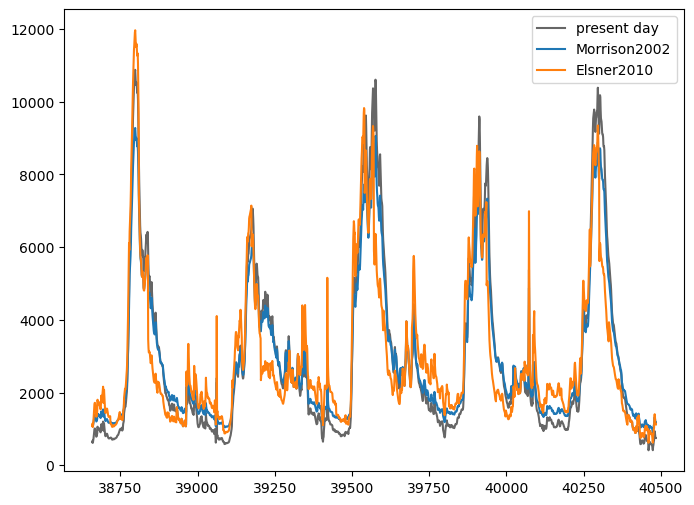

In [100]:
fig, ax = plt.subplots(1,1,figsize=[8,6])

ax.plot(runoff, 'k', label='present day',alpha=0.6)
ax.plot(data.Morrison2002, label='Morrison2002')#,alpha=0.6)
# ax.plot(data.ficklin2016, label='Ficklin2016')#,alpha=0.6)
ax.plot(data.elsner2010, label='Elsner2010')#,alpha=0.6)
ax.legend()